В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [4]:
import pandas as pd
medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

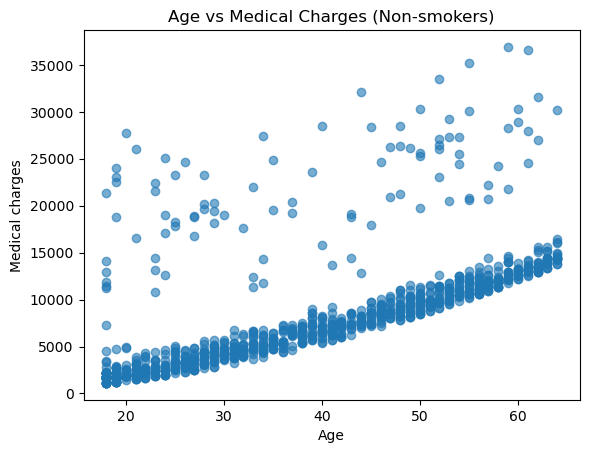

In [6]:
import matplotlib.pyplot as plt

plt.scatter(non_smoker_df['age'], non_smoker_df['charges'], alpha=0.6)
plt.ylabel('Medical charges')
plt.xlabel('Age')
plt.title('Age vs Medical Charges (Non-smokers)')
plt.show()

In [8]:
non_smoker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


MNK_coefs [-2091.42055657   267.24891283]
predictions_MNK [2719.0598744  5391.54900271 6727.79356686 ... 2719.0598744  2719.0598744
 3520.80661289]
RMSE MNK: 4662.505766636395


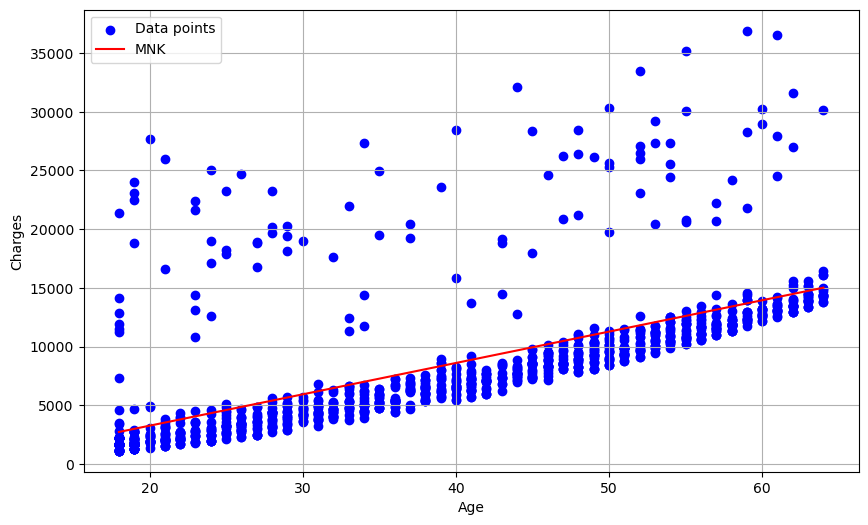

In [10]:
# MNK
import numpy as np

def normal_equations(X, y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta


X = non_smoker_df[['age']].values
y = non_smoker_df['charges'].values

# додаємо intercept (bias term)
X_b = np.c_[np.ones((X.shape[0], 1)), X]

MNK_coefs = normal_equations(X_b, y)
print('MNK_coefs', MNK_coefs)

np.dot(X_b[0], MNK_coefs)

predictions_MNK = np.dot(X_b, MNK_coefs)
print('predictions_MNK', predictions_MNK)

rmse_mnk = np.sqrt(np.mean((predictions_MNK - y) ** 2))
print("RMSE MNK:", rmse_mnk)

# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, color='blue', label='Data points')

# для гарної лінії сортуємо вісь X
sorted_idx = np.argsort(X[:, 0])
plt.plot(X[:, 0][sorted_idx],
         predictions_MNK[sorted_idx],
         color='red',
         label='MNK')

plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Full-Batch градієнтного спуску з numpy 

def full_batch_gradient_descent(X, y, lr, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

# 1) lr = 1e-5
m1, b1, errors1 = full_batch_gradient_descent(X, y, lr=0.00001, epochs=1000)
predictions_fbgd_1 = m1 * X[:, 0] + b1
print("m1, b1:", m1, b1)

# 2) lr = 1e-6
m2, b2, errors2 = full_batch_gradient_descent(X, y, lr=0.000001, epochs=1000)
predictions_fbgd_2 = m2 * X[:, 0] + b2
print("m2, b2:", m2, b2)

# 3) lr = 1e-7
m3, b3, errors3 = full_batch_gradient_descent(X, y, lr=0.0000001, epochs=1000)
predictions_fbgd_3 = m3 * X[:, 0] + b3
print("m3, b3:", m3, b3)

rmse_gd = np.sqrt(np.mean((predictions_fbgd_1 - y) ** 2))  # якщо lr=1e-5 найкращий
print("RMSE GD:", rmse_gd)

rmse1 = np.sqrt(np.mean((predictions_fbgd_1 - y) ** 2))
rmse2 = np.sqrt(np.mean((predictions_fbgd_2 - y) ** 2))
rmse3 = np.sqrt(np.mean((predictions_fbgd_3 - y) ** 2))

print("RMSE lr=1e-5:", rmse1)
print("RMSE lr=1e-6:", rmse2)
print("RMSE lr=1e-7:", rmse3)

best_rmse = min(rmse1, rmse2, rmse3)
print("Best RMSE:", best_rmse)

m1, b1: 220.15455551129122 0.21300652799863293
m2, b2: 213.4575690658104 4.331249162394348
m3, b3: 65.00098750466782 1.4160432218112806
RMSE GD: 4715.349750127827
RMSE lr=1e-5: 4715.349750127827
RMSE lr=1e-6: 4723.647721473958
RMSE lr=1e-7: 8020.833071997775
Best RMSE: 4715.349750127827


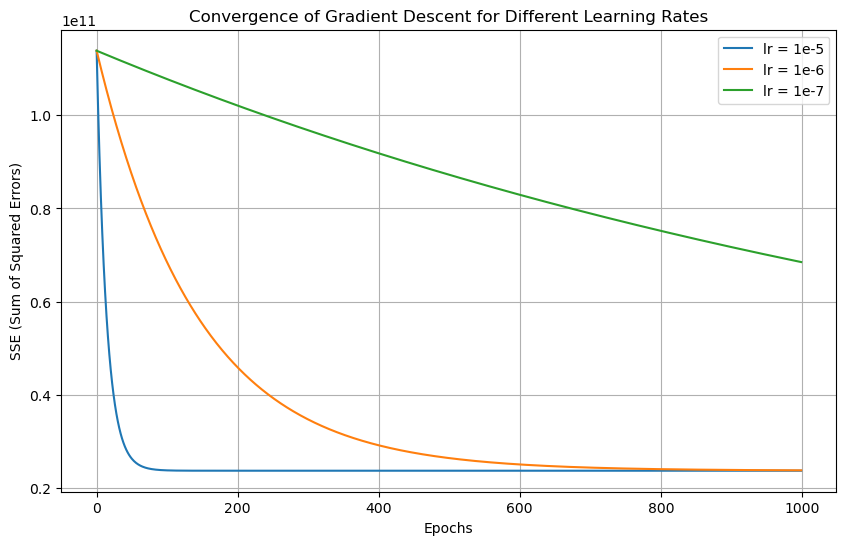

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(errors1, label='lr = 1e-5')
plt.plot(errors2, label='lr = 1e-6')
plt.plot(errors3, label='lr = 1e-7')

plt.xlabel('Epochs')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Convergence of Gradient Descent for Different Learning Rates')

plt.legend()
plt.grid(True)

plt.show()

In [16]:
# Вибір найкращої моделі за RMSE
if best_rmse == rmse1:
    best_m, best_b = m1, b1
    best_predictions = predictions_fbgd_1
    best_lr = 1e-5
elif best_rmse == rmse2:
    best_m, best_b = m2, b2
    best_predictions = predictions_fbgd_2
    best_lr = 1e-6
else:
    best_m, best_b = m3, b3
    best_predictions = predictions_fbgd_3
    best_lr = 1e-7

print(f"Best learning rate: {best_lr}")
print(f"Best parameters: m = {best_m}, b = {best_b}")

Best learning rate: 1e-05
Best parameters: m = 220.15455551129122, b = 0.21300652799863293


Серед протестованих learning rate (1e-5, 1e-6, 1e-7) найкращим виявився 1e-5. 
Він забезпечує найшвидшу збіжність і найменше значення RMSE (~4715).

Менші значення learning rate (1e-6, 1e-7) призводять до повільнішого навчання, 
а у випадку 1e-7 модель не встигає ефективно зійтися за задану кількість епох.

In [21]:
# scikit-learn.LinearRegression

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print("coef:", lin_reg.coef_)
print("intercept:", lin_reg.intercept_)

predictions_sklearn = lin_reg.predict(X)

rmse_sklearn = np.sqrt(np.mean((predictions_sklearn - y) ** 2))
print("RMSE Sklearn:", rmse_sklearn)

coef: [267.24891283]
intercept: -2091.420556565021
RMSE Sklearn: 4662.505766636395


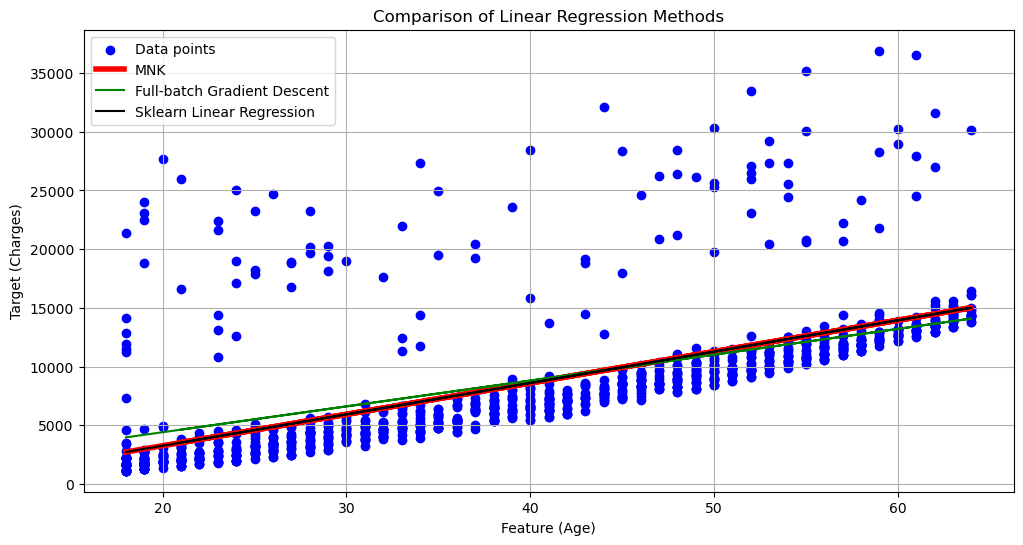

In [23]:
plt.figure(figsize=(12, 6))

plt.scatter(X[:, 0], y, color='blue', label='Data points')
plt.plot(X[:, 0], predictions_MNK, color='red', linewidth=4, label='MNK')
plt.plot(X[:, 0], best_predictions, color='green', label='Full-batch Gradient Descent')
plt.plot(X[:, 0], predictions_sklearn, color='black', label='Sklearn Linear Regression')

plt.title('Comparison of Linear Regression Methods')
plt.xlabel('Feature (Age)')
plt.ylabel('Target (Charges)')
plt.legend()
plt.grid(True)
plt.show()


Усі три методи (МНК, градієнтний спуск та sklearn LinearRegression) дають дуже схожі результати і будують майже однакові лінії регресії.

Метод МНК та sklearn забезпечують практично ідентичні результати, оскільки обидва знаходять аналітичне рішення. Градієнтний спуск при правильно підібраному learning rate (1e-5) також добре наближається до цього рішення.

Отже, всі методи коректно розв’язують задачу, але sklearn є найбільш зручним і стабільним у використанні, тоді як градієнтний спуск потребує підбору параметрів.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

coef: [305.23760211]
intercept: 20294.12812691597
RMSE Sklearn: 10711.00334810241


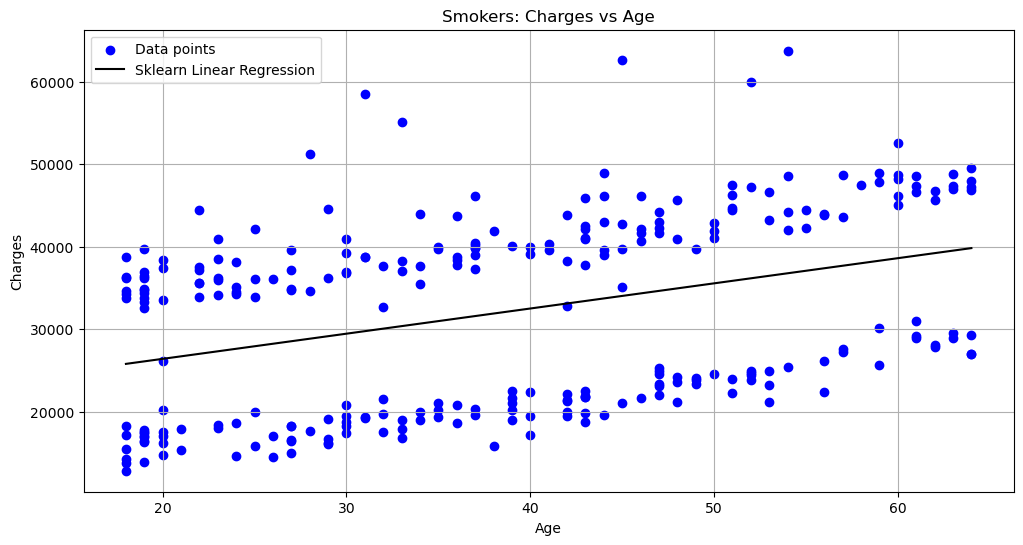

In [34]:
smoker_df = medical_df[medical_df.smoker == 'yes']

X_smoker = smoker_df[['age']].values
y_smoker = smoker_df['charges'].values

lin_reg = LinearRegression()
lin_reg.fit(X_smoker, y_smoker)

print("coef:", lin_reg.coef_)
print("intercept:", lin_reg.intercept_)

predictions_sklearn = lin_reg.predict(X_smoker)

# RMSE
rmse_sklearn = np.sqrt(np.mean((predictions_sklearn - y_smoker) ** 2))
print("RMSE Sklearn:", rmse_sklearn)

sorted_idx = np.argsort(X_smoker[:, 0])

plt.figure(figsize=(12, 6))

plt.scatter(X_smoker[:, 0], y_smoker, color='blue', label='Data points')

plt.plot(X_smoker[:, 0][sorted_idx],
         predictions_sklearn[sorted_idx],
         color='black',
         label='Sklearn Linear Regression')
#plot
plt.title('Smokers: Charges vs Age')
plt.xlabel('Age')
plt.ylabel('Charges')

plt.legend()
plt.grid(True)
plt.show()